<a href="https://colab.research.google.com/github/hanxskuy/Skripshuy/blob/main/bimbingan_after_sidang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL LIBRARY**

In [ ]:
!pip install nibabel -q

**IMPORT LIBRARY**

In [ ]:
import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
import tensorflow as tf

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

**DOWNLOAD DATASET DARI KAGGLE**

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "andrewmvd/liver-tumor-segmentation"
)

print("Dataset tersimpan di:", dataset_path)

Using Colab cache for faster access to the 'liver-tumor-segmentation' dataset.
Dataset tersimpan di: /kaggle/input/liver-tumor-segmentation


**CEK FILE DATASET**

In [ ]:
nii_files = sorted(
    glob.glob(dataset_path + "/**/*.nii", recursive=True)
)

nii_gz_files = sorted(
    glob.glob(dataset_path + "/**/*.nii.gz", recursive=True)
)

all_files = nii_files + nii_gz_files

print("Jumlah File :", len(all_files))

Jumlah File : 182


**PISAHKAN CT DAN MASK**

In [ ]:
ct_files = []
mask_files = []

for file in all_files:

    filename = os.path.basename(file)

    if "volume" in filename.lower():
        ct_files.append(file)

    elif "segmentation" in filename.lower():
        mask_files.append(file)

print("Jumlah CT Scan :", len(ct_files))
print("Jumlah Mask    :", len(mask_files))


Jumlah CT Scan : 51
Jumlah Mask    : 131


**VISUALISASI SAMPLE CT SCAN**

Shape CT Scan : (512, 512, 75)
Shape Mask    : (512, 512, 75)


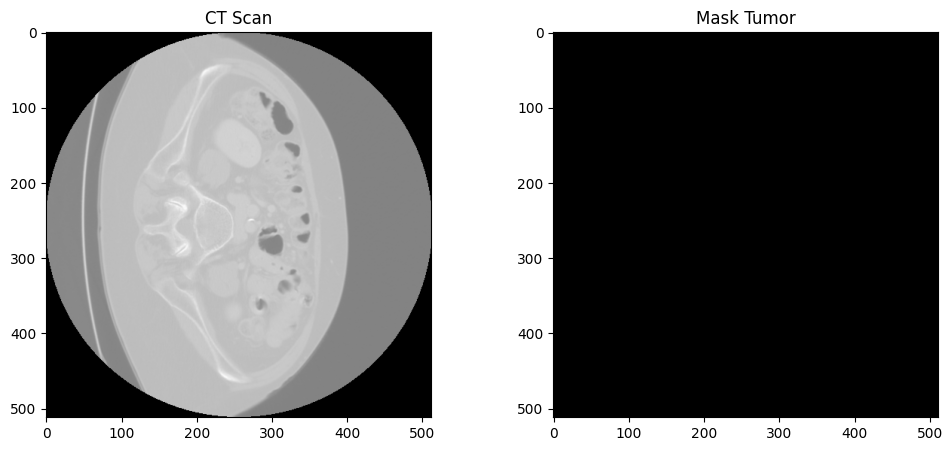

In [ ]:
sample_ct = nib.load(ct_files[0]).get_fdata()
sample_mask = nib.load(mask_files[0]).get_fdata()

print("Shape CT Scan :", sample_ct.shape)
print("Shape Mask    :", sample_mask.shape)

slice_idx = sample_ct.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_ct[:,:,slice_idx], cmap='gray')
plt.title("CT Scan")

plt.subplot(1,2,2)
plt.imshow(sample_mask[:,:,slice_idx], cmap='gray')
plt.title("Mask Tumor")

plt.show()

**PREPROCESSING**

In [ ]:
IMG_SIZE = 128
# CLAHE
# =========================================================

def apply_clahe(image):

    image = np.uint8(image)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    return clahe.apply(image)

# =========================================================
# NORMALISASI
# =========================================================

def normalize_image(image):

    image = image - np.min(image)
    image = image / (np.max(image) + 1e-8)

    return image

# =========================================================
# PREPROCESS SLICE
# =========================================================

def preprocess_slice(image, mask):

    image = normalize_image(image)

    image = (image * 255).astype(np.uint8)

    image = apply_clahe(image)

    image = cv2.GaussianBlur(image, (3,3), 0)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    mask = (mask > 0).astype(np.float32)

    image = np.expand_dims(image, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask

**LOAD SEMUA SLICE**

In [ ]:
images = []
masks = []

for ct_path, mask_path in tqdm(
    zip(ct_files, mask_files),
    total=min(len(ct_files), len(mask_files))
):

    ct_scan = nib.load(ct_path).get_fdata()
    mask_scan = nib.load(mask_path).get_fdata()

    # gunakan jumlah slice terkecil
    total_slices = min(
        ct_scan.shape[2],
        mask_scan.shape[2]
    )

    for i in range(total_slices):

        image_slice = ct_scan[:, :, i]
        mask_slice  = mask_scan[:, :, i]

        # skip slice kosong
        if np.max(mask_slice) > 0:

            image, mask = preprocess_slice(
                image_slice,
                mask_slice
            )

            images.append(image)
            masks.append(mask)

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print("Shape Images :", images.shape)
print("Shape Masks  :", masks.shape)

100%|██████████| 51/51 [03:14<00:00,  3.81s/it]


Shape Images : (4296, 128, 128, 1)
Shape Masks  : (4296, 128, 128, 1)


**SPLIT DATASET**

In [ ]:
#VISUALISASI SAMPLE DATA
X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (3436, 128, 128, 1)
Test  : (860, 128, 128, 1)


**DATA AUGMENTATION**

In [ ]:
augmentation = tf.keras.Sequential([

    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)

])

**METRIC**

In [ ]:
def dice_coef(y_true, y_pred):

    smooth = 1e-6

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (
        (2. * intersection + smooth)
        /
        (
            K.sum(y_true_f)
            +
            K.sum(y_pred_f)
            +
            smooth
        )
    )

**IOU**

In [ ]:
def iou_metric(y_true, y_pred):

    smooth = 1e-6

    intersection = K.sum(y_true * y_pred)

    union = (
        K.sum(y_true)
        +
        K.sum(y_pred)
        -
        intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


In [ ]:
# LOSS FUNCTION
# =========================================================

def dice_loss(y_true, y_pred):

    return 1 - dice_coef(y_true, y_pred)


**CONVOLUTION BLOCK**

In [ ]:
def conv_block(x, filters):

    x = Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)

    x = Activation("relu")(x)

    x = Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)

    x = Activation("relu")(x)

    return x

**ATTENTION BLOCK**

In [ ]:
def attention_block(gating, skip, filters):

    g1 = Conv2D(filters, 1)(gating)

    x1 = Conv2D(filters, 1)(skip)

    psi = Add()([g1, x1])

    psi = Activation("relu")(psi)

    psi = Conv2D(1, 1)(psi)

    psi = Activation("sigmoid")(psi)

    out = Multiply()([skip, psi])

    return out

**ENCODER BLOCK**

In [ ]:
def encoder_block(x, filters):

    c = conv_block(x, filters)

    p = MaxPooling2D((2,2))(c)

    return c, p

**DECODER BLOCK**

In [ ]:
def decoder_block(x, skip, filters):

    x = UpSampling2D((2,2))(x)

    skip = attention_block(
        x,
        skip,
        filters
    )

    x = Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

**BUILD ATTENTION U-NET**

In [ ]:
def build_attention_unet(input_shape):

    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = Model(inputs, outputs)

    return model

**BUILD MODEL**

In [ ]:
model = build_attention_unet(
    (IMG_SIZE, IMG_SIZE, 1)
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 32,448,709 (123.78 MB)

 Trainable params: 32,436,933 (123.74 MB)

 Non-trainable params: 11,776 (46.00 KB)

**COMPILE MODEL**

In [ ]:
model.compile(

    optimizer=Adam(1e-4),

    loss=dice_loss,

    metrics=[
        dice_coef,
        iou_metric,
        "accuracy"
    ]
)

**CALLBACK**

In [ ]:
callbacks = [

    EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_attention_unet.h5",
        save_best_only=True
    ),

    ReduceLROnPlateau(
        patience=5
    )
]

**TRAINING**

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=50,

    batch_size=8,

    callbacks=callbacks
)

Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8771 - dice_coef: 0.4062 - iou_metric: 0.2636 - loss: 0.5938

430/430 ━━━━━━━━━━━━━━━━━━━━ 187s 297ms/step - accuracy: 0.9358 - dice_coef: 0.5077 - iou_metric: 0.3502 - loss: 0.4925 - val_accuracy: 0.9372 - val_dice_coef: 0.1026 - val_iou_metric: 0.0546 - val_loss: 0.8971 - learning_rate: 1.0000e-04
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9788 - dice_coef: 0.6932 - iou_metric: 0.5361 - loss: 0.3068

430/430 ━━━━━━━━━━━━━━━━━━━━ 91s 212ms/step - accuracy: 0.9814 - dice_coef: 0.7328 - iou_metric: 0.5838 - loss: 0.2673 - val_accuracy: 0.9798 - val_dice_coef: 0.7762 - val_iou_metric: 0.6365 - val_loss: 0.2234 - learning_rate: 1.0000e-04
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9873 - dice_coef: 0.8218 - iou_metric: 0.7007 - loss: 0.1782

430/430 ━━━━━━━━━━━━━━━━━━━━ 95s 221ms/step - accuracy: 0.9884 - dice_coef: 0.8419 - iou_metric: 0.7298 - loss: 0.1580 - val_accuracy: 0.9830 - val_dice_coef: 0.8035 - val_iou_metric: 0.6741 - val_loss: 0.1965 - learning_rate: 1.0000e-04
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9893 - dice_coef: 0.8721 - iou_metric: 0.7755 - loss: 0.1279

430/430 ━━━━━━━━━━━━━━━━━━━━ 96s 224ms/step - accuracy: 0.9902 - dice_coef: 0.8854 - iou_metric: 0.7962 - loss: 0.1146 - val_accuracy: 0.9911 - val_dice_coef: 0.9015 - val_iou_metric: 0.8216 - val_loss: 0.0984 - learning_rate: 1.0000e-04
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9926 - dice_coef: 0.9144 - iou_metric: 0.8431 - loss: 0.0856

...

430/430 ━━━━━━━━━━━━━━━━━━━━ 100s 234ms/step - accuracy: 0.9989 - dice_coef: 0.9908 - iou_metric: 0.9818 - loss: 0.0092 - val_accuracy: 0.9982 - val_dice_coef: 0.9858 - val_iou_metric: 0.9720 - val_loss: 0.0142 - learning_rate: 1.0000e-05
Epoch 42/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9989 - dice_coef: 0.9910 - iou_metric: 0.9821 - loss: 0.0090

430/430 ━━━━━━━━━━━━━━━━━━━━ 100s 233ms/step - accuracy: 0.9989 - dice_coef: 0.9909 - iou_metric: 0.9821 - loss: 0.0091 - val_accuracy: 0.9982 - val_dice_coef: 0.9858 - val_iou_metric: 0.9721 - val_loss: 0.0141 - learning_rate: 1.0000e-05
Epoch 43/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 84s 195ms/step - accuracy: 0.9989 - dice_coef: 0.9911 - iou_metric: 0.9824 - loss: 0.0089 - val_accuracy: 0.9982 - val_dice_coef: 0.9857 - val_iou_metric: 0.9719 - val_loss: 0.0142 - learning_rate: 1.0000e-05
Epoch 44/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 84s 194ms/step - accuracy: 0.9989 - dice_coef: 0.9911 - iou_metric: 0.9823 - loss: 0.0089 - val_accuracy: 0.9982 - val_dice_coef: 0.9856 - val_iou_metric: 0.9717 - val_loss: 0.0143 - learning_rate: 1.0000e-05
Epoch 45/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9989 - dice_coef: 0.9912 - iou_metric: 0.9826 - loss: 0.0088

430/430 ━━━━━━━━━━━━━━━━━━━━ 101s 235ms/step - accuracy: 0.9989 - dice_coef: 0.9912 - iou_metric: 0.9827 - loss: 0.0088 - val_accuracy: 0.9983 - val_dice_coef: 0.9859 - val_iou_metric: 0.9723 - val_loss: 0.0140 - learning_rate: 1.0000e-05
Epoch 46/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9990 - dice_coef: 0.9914 - iou_metric: 0.9830 - loss: 0.0086

430/430 ━━━━━━━━━━━━━━━━━━━━ 100s 233ms/step - accuracy: 0.9989 - dice_coef: 0.9914 - iou_metric: 0.9830 - loss: 0.0086 - val_accuracy: 0.9983 - val_dice_coef: 0.9861 - val_iou_metric: 0.9727 - val_loss: 0.0138 - learning_rate: 1.0000e-05
Epoch 47/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 84s 195ms/step - accuracy: 0.9990 - dice_coef: 0.9915 - iou_metric: 0.9832 - loss: 0.0085 - val_accuracy: 0.9983 - val_dice_coef: 0.9861 - val_iou_metric: 0.9726 - val_loss: 0.0139 - learning_rate: 1.0000e-05
Epoch 48/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 83s 194ms/step - accuracy: 0.9990 - dice_coef: 0.9915 - iou_metric: 0.9831 - loss: 0.0085 - val_accuracy: 0.9983 - val_dice_coef: 0.9861 - val_iou_metric: 0.9727 - val_loss: 0.0138 - learning_rate: 1.0000e-05
Epoch 49/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9990 - dice_coef: 0.9917 - iou_metric: 0.9836 - loss: 0.0083

430/430 ━━━━━━━━━━━━━━━━━━━━ 107s 249ms/step - accuracy: 0.9990 - dice_coef: 0.9916 - iou_metric: 0.9833 - loss: 0.0084 - val_accuracy: 0.9983 - val_dice_coef: 0.9864 - val_iou_metric: 0.9731 - val_loss: 0.0136 - learning_rate: 1.0000e-05
Epoch 50/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 84s 195ms/step - accuracy: 0.9990 - dice_coef: 0.9917 - iou_metric: 0.9836 - loss: 0.0083 - val_accuracy: 0.9983 - val_dice_coef: 0.9862 - val_iou_metric: 0.9729 - val_loss: 0.0137 - learning_rate: 1.0000e-05


**VISUALISASI TRAINING DICE**

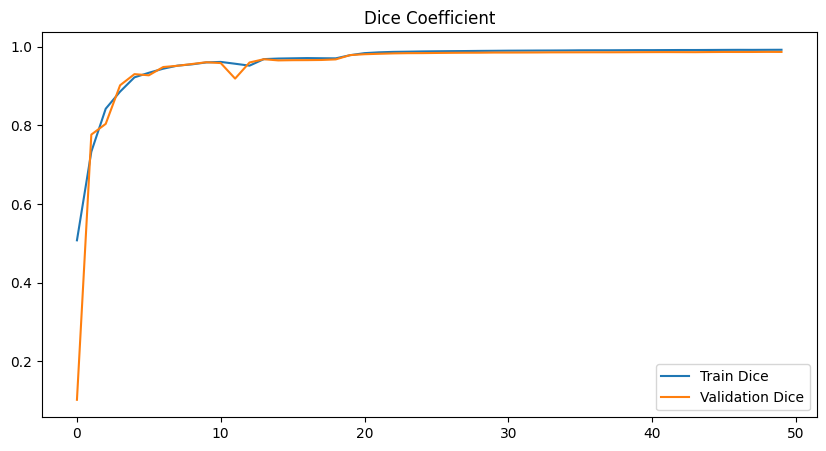

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['dice_coef'],
    label='Train Dice'
)

plt.plot(
    history.history['val_dice_coef'],
    label='Validation Dice'
)

plt.title("Dice Coefficient")

plt.legend()

plt.show()

**VISUALISASI TRAINING IOU**

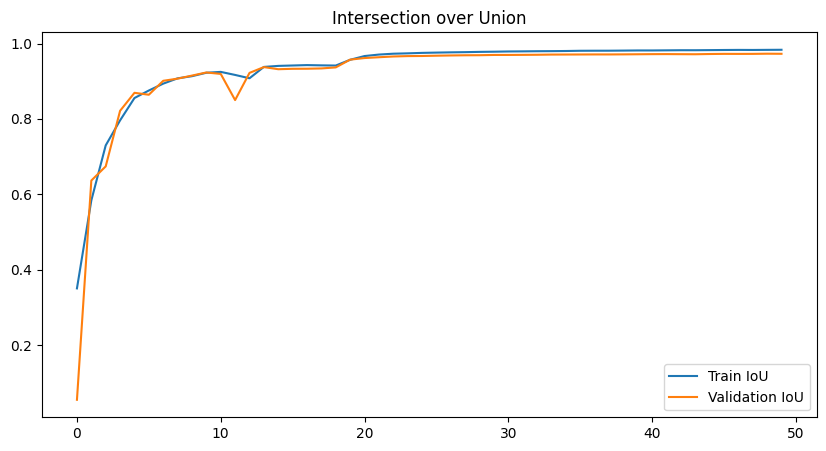

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['iou_metric'],
    label='Train IoU'
)

plt.plot(
    history.history['val_iou_metric'],
    label='Validation IoU'
)

plt.title("Intersection over Union")

plt.legend()

plt.show()

**EVALUASI MODEL**

In [ ]:
results = model.evaluate(
    X_test,
    y_test
)

print("Loss       :", results[0])
print("Dice Score :", results[1])
print("IoU Score  :", results[2])
print("Accuracy   :", results[3])

27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 917ms/step - accuracy: 0.9983 - dice_coef: 0.9867 - iou_metric: 0.9738 - loss: 0.0133
Loss       : 0.01328547578305006
Dice Score : 0.986713707447052
IoU Score  : 0.9737856984138489
Accuracy   : 0.9983012080192566


**PREDIKSI**

In [ ]:
predictions = model.predict(X_test)

predictions = (
    predictions > 0.5
).astype(np.uint8)

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step


**VISUALISASI HASIL SEGMENTASI**

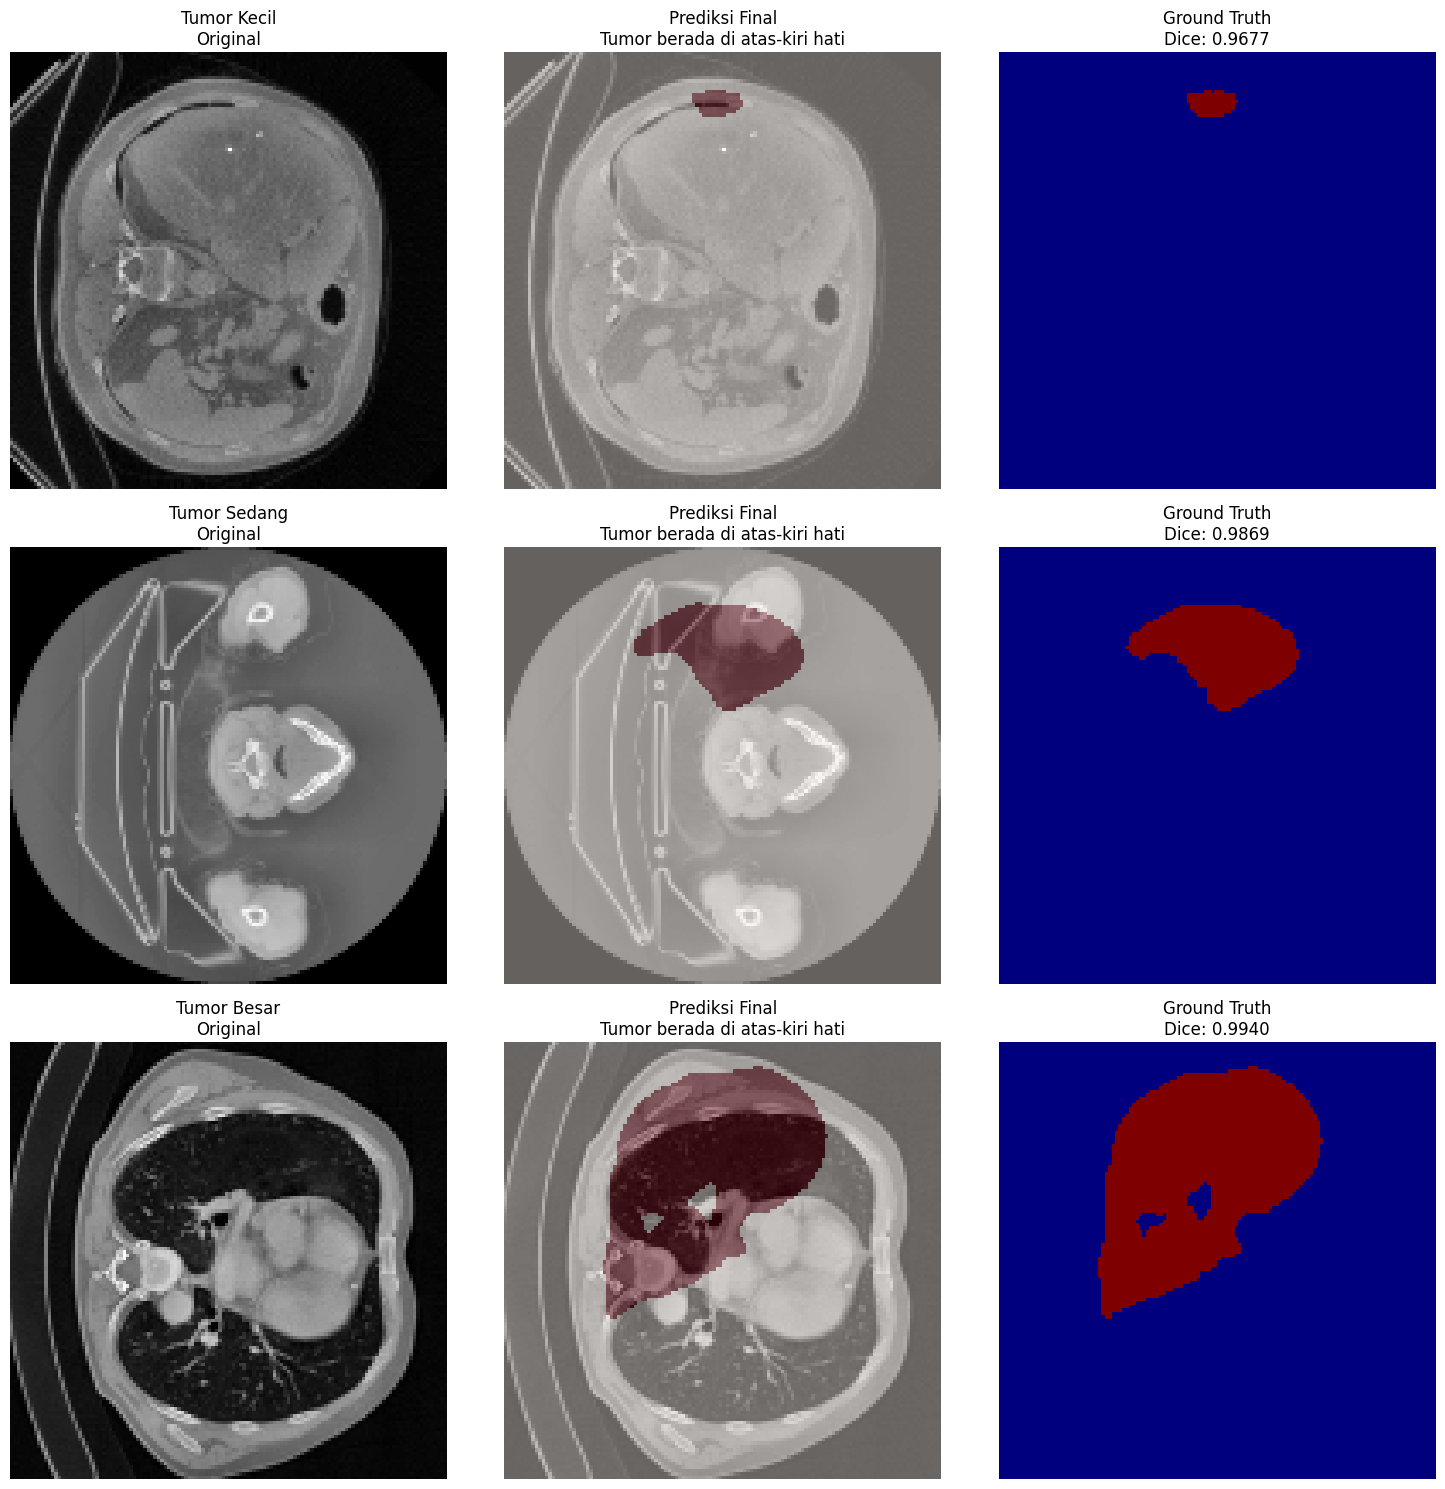

In [ ]:
# =========================================================
# VISUALISASI HASIL SEGMENTASI
# PERBANDINGAN TUMOR KECIL - SEDANG - BESAR
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

# =========================================================
# HITUNG LUAS TUMOR
# =========================================================

tumor_sizes = []

for i in range(len(y_test)):

    mask_area = np.sum(y_test[i] > 0)

    tumor_sizes.append((i, mask_area))

# =========================================================
# SORT BERDASARKAN UKURAN TUMOR
# =========================================================

tumor_sizes = sorted(
    tumor_sizes,
    key=lambda x: x[1]
)

# =========================================================
# AMBIL SAMPLE
# =========================================================

small_idx  = tumor_sizes[len(tumor_sizes)//10][0]
medium_idx = tumor_sizes[len(tumor_sizes)//2][0]
large_idx  = tumor_sizes[-1][0]

selected_indices = [

    ("Tumor Kecil", small_idx),
    ("Tumor Sedang", medium_idx),
    ("Tumor Besar", large_idx)

]

# =========================================================
# DICE SCORE NUMPY
# =========================================================

def dice_score_np(y_true, y_pred):

    smooth = 1e-6

    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    intersection = np.sum(y_true_f * y_pred_f)

    return (
        (2. * intersection + smooth)
        /
        (
            np.sum(y_true_f)
            +
            np.sum(y_pred_f)
            +
            smooth
        )
    )

# =========================================================
# DETEKSI LOKASI TUMOR
# =========================================================

def get_tumor_location(mask):

    coords = np.argwhere(mask.squeeze() > 0)

    if len(coords) == 0:
        return "Tumor Tidak Terdeteksi"

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    center_x = (x_min + x_max) // 2
    center_y = (y_min + y_max) // 2

    vertical = "atas" if center_y < 64 else "bawah"
    horizontal = "kiri" if center_x < 64 else "kanan"

    return f"Tumor berada di {vertical}-{horizontal} hati"

# =========================================================
# VISUALISASI
# =========================================================

fig, axes = plt.subplots(
    len(selected_indices),
    3,
    figsize=(15, 15)
)

for row, (label, idx_visual) in enumerate(selected_indices):

    # =====================================================
    # LOAD DATA
    # =====================================================

    img = X_test[idx_visual]
    pred = predictions[idx_visual]
    true = y_test[idx_visual]

    # =====================================================
    # ENHANCE CT IMAGE
    # =====================================================

    display_img = (img.squeeze() * 255).astype(np.uint8)

    display_img = cv2.normalize(
        display_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # =====================================================
    # LOKASI & DICE
    # =====================================================

    location = get_tumor_location(pred)

    dice_value = dice_score_np(
        true,
        pred
    )

    # =====================================================
    # ORIGINAL
    # =====================================================

    axes[row, 0].imshow(
        display_img,
        cmap='gray'
    )

    axes[row, 0].set_title(
        f"{label}\nOriginal",
        fontsize=12
    )

    axes[row, 0].axis("off")

    # =====================================================
    # PREDICTION OVERLAY
    # =====================================================

    axes[row, 1].imshow(
        display_img,
        cmap='gray'
    )

    axes[row, 1].imshow(
        pred.squeeze(),
        alpha=0.4,
        cmap='Reds'
    )

    axes[row, 1].set_title(
        f"Prediksi Final\n{location}",
        fontsize=12
    )

    axes[row, 1].axis("off")

    # =====================================================
    # GROUND TRUTH
    # =====================================================

    axes[row, 2].imshow(
        true.squeeze(),
        cmap='jet'
    )

    axes[row, 2].set_title(
        f"Ground Truth\nDice: {dice_value:.4f}",
        fontsize=12
    )

    axes[row, 2].axis("off")

# =========================================================
# TAMPILKAN
# =========================================================

plt.tight_layout()

plt.show()

**LOKALISASI TUMOR**

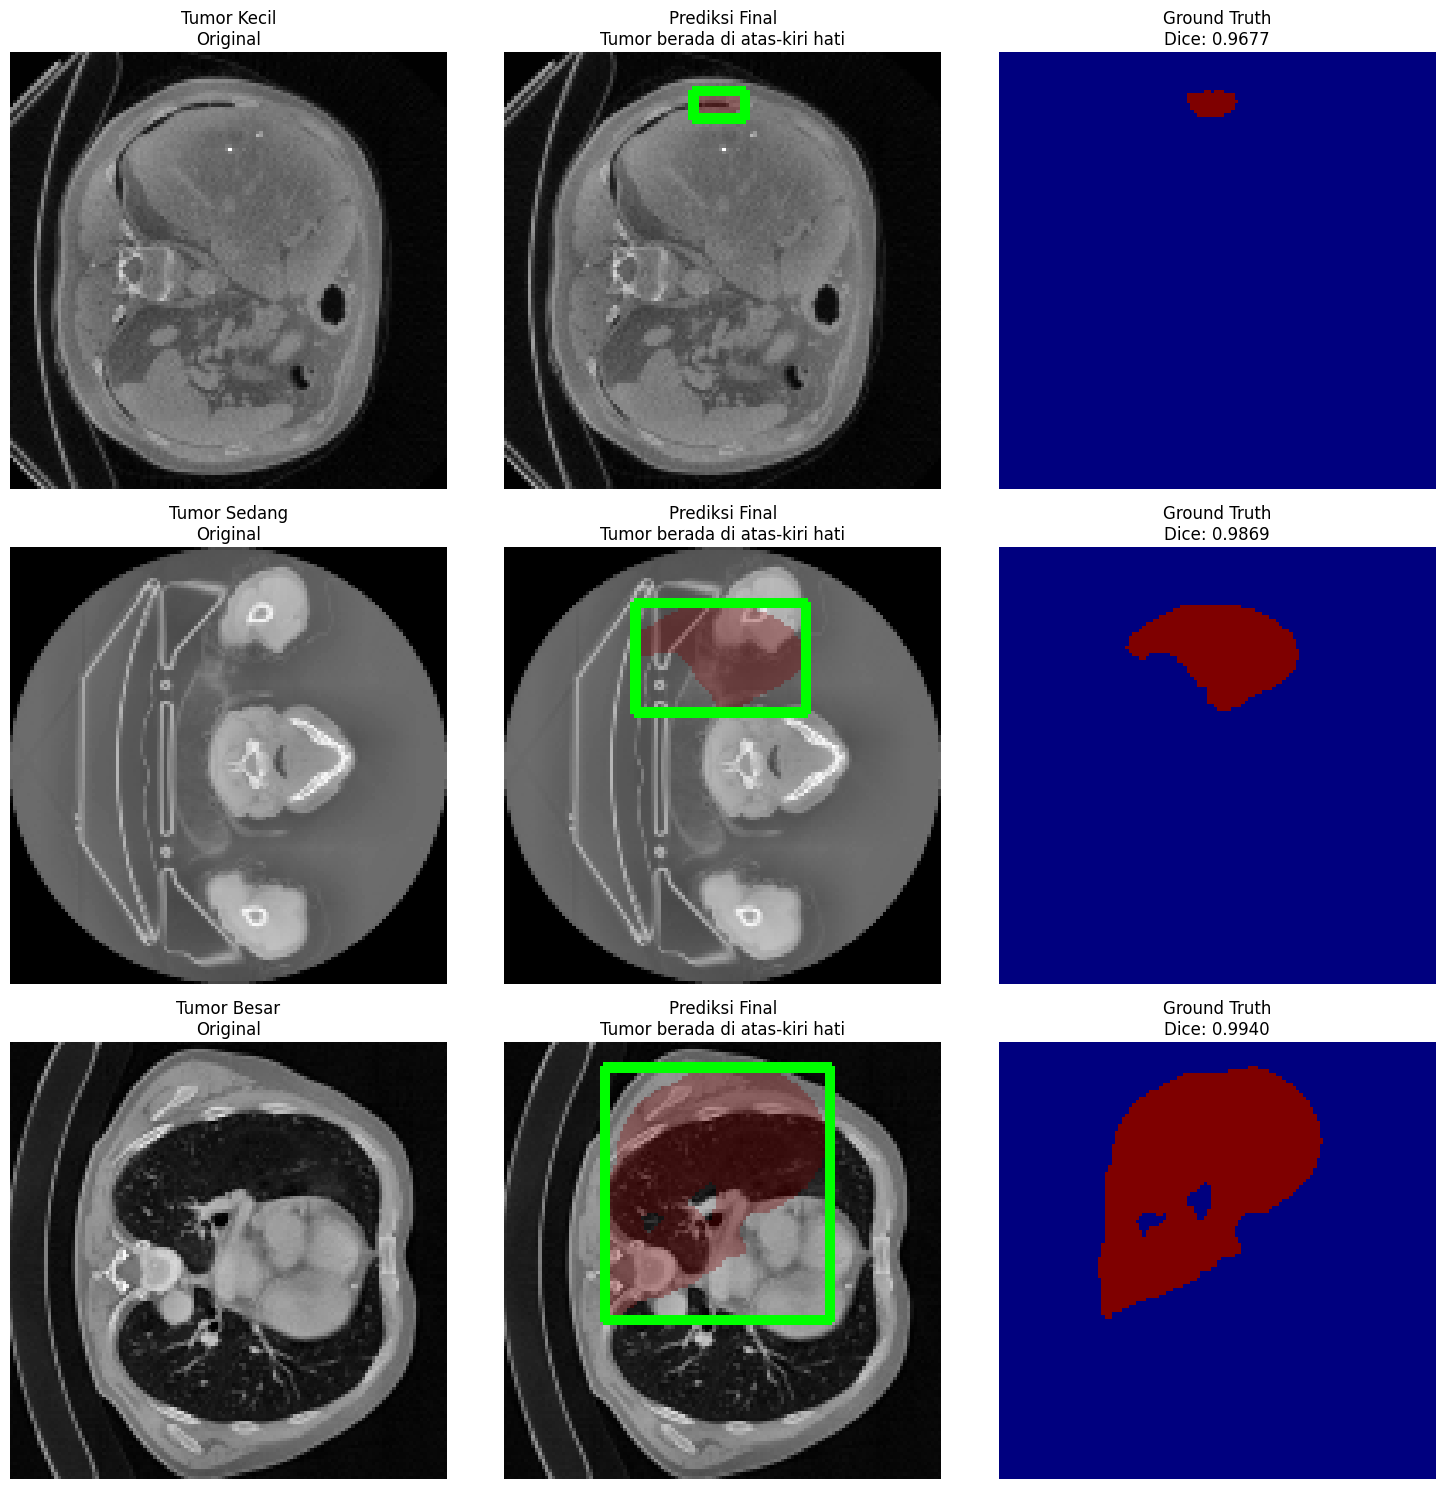

In [ ]:
# =========================================================
# VISUALISASI SEGMENTASI DAN LOKALISASI TUMOR
# TUMOR KECIL - SEDANG - BESAR
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

# =========================================================
# HITUNG LUAS TUMOR
# =========================================================

tumor_sizes = []

for i in range(len(y_test)):

    mask_area = np.sum(
        y_test[i] > 0
    )

    tumor_sizes.append(
        (i, mask_area)
    )

# =========================================================
# SORT BERDASARKAN LUAS
# =========================================================

tumor_sizes = sorted(
    tumor_sizes,
    key=lambda x: x[1]
)

# =========================================================
# AMBIL SAMPLE
# =========================================================

small_idx = tumor_sizes[
    len(tumor_sizes)//10
][0]

medium_idx = tumor_sizes[
    len(tumor_sizes)//2
][0]

large_idx = tumor_sizes[-1][0]

selected_indices = [

    ("Tumor Kecil", small_idx),
    ("Tumor Sedang", medium_idx),
    ("Tumor Besar", large_idx)

]

# =========================================================
# DICE SCORE
# =========================================================

def dice_score_np(y_true, y_pred):

    smooth = 1e-6

    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    intersection = np.sum(
        y_true_f * y_pred_f
    )

    return (
        (2. * intersection + smooth)
        /
        (
            np.sum(y_true_f)
            +
            np.sum(y_pred_f)
            +
            smooth
        )
    )

# =========================================================
# DETEKSI POSISI TUMOR
# =========================================================

def get_tumor_location(mask):

    coords = np.argwhere(
        mask.squeeze() > 0
    )

    if len(coords) == 0:
        return "Tumor tidak terdeteksi"

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    center_x = (x_min + x_max) // 2
    center_y = (y_min + y_max) // 2

    vertical = (
        "atas"
        if center_y < 64
        else "bawah"
    )

    horizontal = (
        "kiri"
        if center_x < 64
        else "kanan"
    )

    return (
        f"Tumor berada di "
        f"{vertical}-{horizontal} hati"
    )

# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    len(selected_indices),
    3,
    figsize=(15, 15)
)

# =========================================================
# LOOP VISUALISASI
# =========================================================

for row, (label, idx_visual) in enumerate(selected_indices):

    # =====================================================
    # LOAD DATA
    # =====================================================

    img = X_test[idx_visual]
    pred = predictions[idx_visual]
    true = y_test[idx_visual]

    # =====================================================
    # ENHANCE CT IMAGE
    # =====================================================

    display_img = (
        img.squeeze() * 255
    ).astype(np.uint8)

    display_img = cv2.normalize(
        display_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # =====================================================
    # RGB IMAGE
    # =====================================================

    localized = cv2.cvtColor(
        display_img,
        cv2.COLOR_GRAY2BGR
    )

    # =====================================================
    # OVERLAY MASK PREDIKSI
    # =====================================================

    overlay = localized.copy()

    overlay[
        pred.squeeze() > 0
    ] = [120, 0, 0]

    alpha = 0.35

    localized = cv2.addWeighted(
        overlay,
        alpha,
        localized,
        1 - alpha,
        0
    )

    # =====================================================
    # CONTOUR
    # =====================================================

    contours, _ = cv2.findContours(

        pred.squeeze().astype(np.uint8),

        cv2.RETR_EXTERNAL,

        cv2.CHAIN_APPROX_SIMPLE
    )

    # =====================================================
    # BOUNDING BOX
    # =====================================================

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(

            localized,

            (x, y),

            (x+w, y+h),

            (0,255,0),

            2
        )

    # =====================================================
    # LOKASI & DICE
    # =====================================================

    location = get_tumor_location(pred)

    dice_value = dice_score_np(
        true,
        pred
    )

    # =====================================================
    # ORIGINAL
    # =====================================================

    axes[row, 0].imshow(
        display_img,
        cmap='gray'
    )

    axes[row, 0].set_title(
        f"{label}\nOriginal",
        fontsize=12
    )

    axes[row, 0].axis("off")

    # =====================================================
    # PREDIKSI
    # =====================================================

    axes[row, 1].imshow(localized)

    axes[row, 1].set_title(
        f"Prediksi Final\n{location}",
        fontsize=12
    )

    axes[row, 1].axis("off")

    # =====================================================
    # GROUND TRUTH
    # =====================================================

    axes[row, 2].imshow(
        true.squeeze(),
        cmap='jet'
    )

    axes[row, 2].set_title(
        f"Ground Truth\nDice: {dice_value:.4f}",
        fontsize=12
    )

    axes[row, 2].axis("off")

# =========================================================
# SHOW
# =========================================================

plt.tight_layout()

plt.show()

**SAVE MODEL**

In [ ]:
model.save(
    "attention_unet_liver_tumor.h5"
)

print("Model berhasil disimpan!")

Model berhasil disimpan!
